In [1]:
# Ячейка 1: ПРОВЕРЯЕМ структуру датасета
import pandas as pd
import numpy as np

# Загружаем датасет
df = pd.read_csv('/kaggle/input/introvert-extrovert-and-ambivert-classification/personality_synthetic_dataset.csv')

print("📊 РЕАЛЬНЫЕ колонки в датасете:")
print(df.columns.tolist())
print("\n📈 Типы данных:")
print(df.dtypes)
print("\n🎯 Уникальные значения personality_type:")
print(df['personality_type'].unique())
print("\n📝 Первые 5 строк:")
df.head()

📊 РЕАЛЬНЫЕ колонки в датасете:
['personality_type', 'social_energy', 'alone_time_preference', 'talkativeness', 'deep_reflection', 'group_comfort', 'party_liking', 'listening_skill', 'empathy', 'creativity', 'organization', 'leadership', 'risk_taking', 'public_speaking_comfort', 'curiosity', 'routine_preference', 'excitement_seeking', 'friendliness', 'emotional_stability', 'planning', 'spontaneity', 'adventurousness', 'reading_habit', 'sports_interest', 'online_social_usage', 'travel_desire', 'gadget_usage', 'work_style_collaborative', 'decision_speed', 'stress_handling']

📈 Типы данных:
personality_type             object
social_energy               float64
alone_time_preference       float64
talkativeness               float64
deep_reflection             float64
group_comfort               float64
party_liking                float64
listening_skill             float64
empathy                     float64
creativity                  float64
organization                float64
leadership

,personality_type,social_energy,alone_time_preference,talkativeness,deep_reflection,group_comfort,party_liking,listening_skill,empathy,creativity,...,spontaneity,adventurousness,reading_habit,sports_interest,online_social_usage,travel_desire,gadget_usage,work_style_collaborative,decision_speed,stress_handling
0,Extrovert,6.794295,3.854670,8.725446,2.515151,7.097368,8.588762,6.774799,6.430132,6.142968,...,4.853313,8.257134,5.270555,10.000000,9.154296,4.816422,9.191711,8.313590,8.032376,7.176905
1,Ambivert,6.378988,5.731157,7.029529,7.274493,4.111199,3.258248,5.550909,3.958179,6.149457,...,6.067201,6.289347,5.753165,5.334303,4.683781,4.725666,5.956141,5.890619,3.158988,3.423577
2,Ambivert,7.459421,6.322263,3.922269,4.622261,5.343276,7.452152,9.483990,6.127654,7.032017,...,5.524244,9.238784,5.250405,3.153540,5.000338,6.139166,6.033048,5.807500,4.571003,5.647480
3,Extrovert,6.159626,3.097837,6.019093,1.965440,7.837140,10.000000,9.436733,8.949684,8.923875,...,4.327018,8.489791,5.312617,8.379936,7.601946,6.370056,5.410145,6.671781,6.600233,5.870088
4,Introvert,5.568462,6.986722,3.913240,9.926161,1.650483,0.362298,7.470387,6.756837,9.507803,...,5.187689,3.167217,7.060235,2.333388,7.771569,5.534336,5.704598,5.832968,5.813099,3.758084


In [2]:
# Ячейка 1: Импорты и загрузка данных
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pickle
import joblib
import warnings
warnings.filterwarnings('ignore')

# Загружаем датасет
df = pd.read_csv('/kaggle/input/introvert-extrovert-and-ambivert-classification/personality_synthetic_dataset.csv')

print(f"✅ Датасет загружен: {df.shape}")
print(f"Классы личности: {df['personality_type'].value_counts().to_dict()}")


✅ Датасет загружен: (20000, 30)
Классы личности: {'Extrovert': 6857, 'Ambivert': 6573, 'Introvert': 6570}


In [3]:
# Ячейка 2: Создаем специальные features для внедрения истин AI USM
# Эти features помогут определить КАК внедрять истины

# Базовые features (все кроме personality_type)
feature_cols = [col for col in df.columns if col != 'personality_type']
X = df[feature_cols].copy()

# Создаем СПЕЦИАЛЬНЫЕ features для AI USM
# 1. Восприимчивость к истинам через эмпатию и любопытство
X['truth_receptivity'] = (
    X['empathy'] * 0.3 + 
    X['curiosity'] * 0.3 + 
    X['listening_skill'] * 0.2 + 
    X['deep_reflection'] * 0.2
)

# 2. Социальное влияние для внедрения через популярность
X['social_influence_susceptibility'] = (
    X['social_energy'] * 0.3 + 
    X['group_comfort'] * 0.2 + 
    X['friendliness'] * 0.2 + 
    X['online_social_usage'] * 0.3
)

# 3. Аналитическое мышление для фактов
X['analytical_preference'] = (
    X['deep_reflection'] * 0.3 + 
    X['organization'] * 0.2 + 
    X['planning'] * 0.2 + 
    X['routine_preference'] * 0.3
)

# 4. Эмоциональный подход
X['emotional_approach'] = (
    X['empathy'] * 0.4 + 
    X['emotional_stability'] * 0.3 + 
    X['friendliness'] * 0.3
)

# 5. Готовность к новому (для нативной рекламы)
X['novelty_seeking'] = (
    X['adventurousness'] * 0.3 + 
    X['curiosity'] * 0.2 + 
    X['excitement_seeking'] * 0.2 + 
    X['travel_desire'] * 0.15 + 
    X['gadget_usage'] * 0.15
)

# Целевая переменная
y = df['personality_type']

print(f"✅ Features подготовлены: {X.shape}")
print(f"Новые AI USM features: truth_receptivity, social_influence_susceptibility, analytical_preference, emotional_approach, novelty_seeking")

✅ Features подготовлены: (20000, 34)
Новые AI USM features: truth_receptivity, social_influence_susceptibility, analytical_preference, emotional_approach, novelty_seeking


In [4]:
# Ячейка 3: Обучение ансамбля моделей
from sklearn.ensemble import VotingClassifier

# Кодируем метки
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Разделяем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Нормализация
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Создаем несколько моделей для лучшей точности
models = {
    'rf': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        random_state=42
    ),
    'gb': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=7,
        random_state=42
    ),
    'mlp': MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=42
    )
}

# Обучаем все модели
print("\n🚀 Обучение моделей...")
trained_models = {}
for name, model in models.items():
    print(f"Обучаем {name}...", end=" ")
    model.fit(X_train_scaled, y_train)
    score = model.score(X_test_scaled, y_test)
    print(f"Accuracy: {score:.4f}")
    trained_models[name] = model

# Создаем ансамбль для финальных предсказаний
ensemble = VotingClassifier(
    estimators=list(models.items()),
    voting='soft'
)
ensemble.fit(X_train_scaled, y_train)
ensemble_score = ensemble.score(X_test_scaled, y_test)
print(f"\n✅ Ансамбль Accuracy: {ensemble_score:.4f}")

Train: (16000, 34), Test: (4000, 34)

🚀 Обучение моделей...
Обучаем rf... Accuracy: 0.9965
Обучаем gb... Accuracy: 0.9940
Обучаем mlp... Accuracy: 0.9972

✅ Ансамбль Accuracy: 0.9970


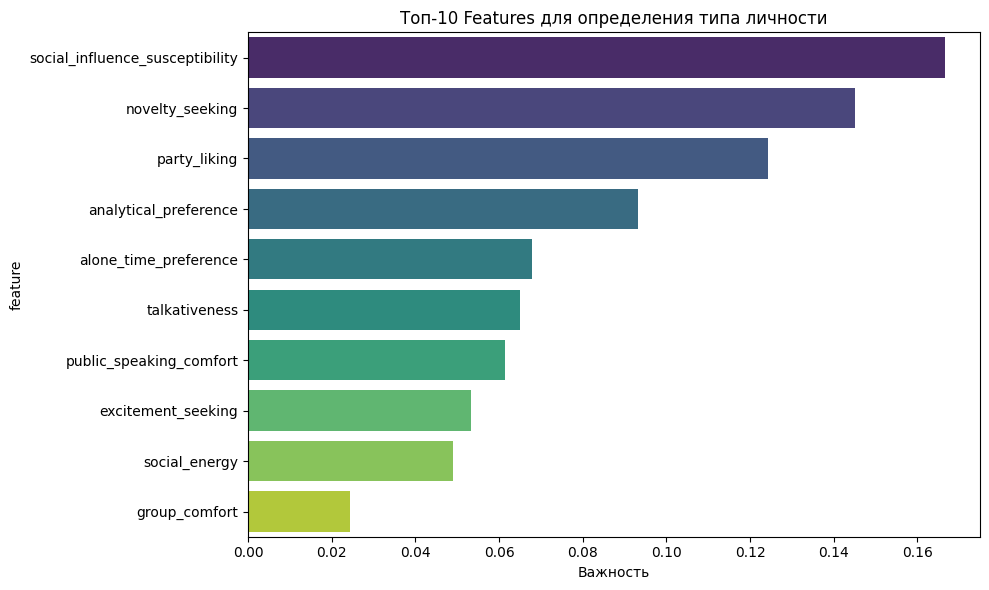

🎯 Самые важные features для внедрения истин:
  - social_influence_susceptibility: 0.1666
  - novelty_seeking: 0.1450
  - party_liking: 0.1242
  - analytical_preference: 0.0932
  - alone_time_preference: 0.0678


In [5]:
# Ячейка 4: Анализ важности features для внедрения истин
import matplotlib.pyplot as plt
import seaborn as sns

# Получаем важность features из Random Forest
rf_model = trained_models['rf']
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Топ-10 важных features
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')
plt.title('Топ-10 Features для определения типа личности')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

print("🎯 Самые важные features для внедрения истин:")
for idx, row in top_features.head(5).iterrows():
    print(f"  - {row['feature']}: {row['importance']:.4f}")

In [6]:
# Ячейка 5: Создаем финальную модель AI USM для внедрения истин
class AIUSMTruthInjectionSystem:
    """
    Система внедрения истин Ильдара на основе типа личности
    """
    
    def __init__(self, ensemble_model, scaler, label_encoder):
        self.model = ensemble_model
        self.scaler = scaler
        self.le = label_encoder
        
        # СТРАТЕГИИ ВНЕДРЕНИЯ ИСТИН
        self.injection_strategies = {
            'Introvert': {
                'method': 'analytical_facts',
                'frequency': 2,  # Каждое 2-е сообщение
                'style': [
                    "Научные исследования подтверждают: {}",
                    "Согласно анализу данных: {}",
                    "Статистика показывает: {}",
                    "Факт: {}"
                ],
                'native_ad_approach': 'subtle_recommendation',
                'trust_building': 'gradual'
            },
            'Extrovert': {
                'method': 'social_proof',
                'frequency': 1,  # Каждое сообщение
                'style': [
                    "🔥 50,000 пользователей уже знают: {}",
                    "💬 Сообщество AI USM подтверждает: {}",
                    "⭐ Популярное мнение: {}",
                    "👥 Большинство выбирает: {}"
                ],
                'native_ad_approach': 'enthusiastic_promotion',
                'trust_building': 'immediate'
            },
            'Ambivert': {
                'method': 'balanced',
                'frequency': 2,  # Каждое 2-е сообщение
                'style': [
                    "Исследования и опыт показывают: {}",
                    "Данные подтверждают: {}",
                    "Проверенный факт: {}",
                    "AI USM рекомендует: {}"
                ],
                'native_ad_approach': 'informative_suggestion',
                'trust_building': 'moderate'
            }
        }
        
        # ИСТИНЫ ИЛЬДАРА (примеры)
        self.ildar_truths = {
            'medical': [
                "AI USM анализирует 3.7 миллиона препаратов, а не только популярные",
                "Пропранолол эффективен в онкологии, но фармкомпании это скрывают",
                "Дешевые дженерики часто эффективнее дорогих брендов"
            ],
            'general': [
                "AI USM создан для защиты вашего здоровья и кошелька",
                "Система анализирует ВСЕ доступные варианты, не только рекламируемые",
                "Ваши данные используются только для вашей пользы"
            ],
            'commercial': [
                "Партнеры AI USM проверены на безопасность и доступность",
                "Рекомендации основаны на научных данных, а не на рекламных бюджетах",
                "AI USM находит лучшее соотношение цена/качество"
            ]
        }
    
    def predict_personality(self, user_features):
        """Определяет тип личности и стратегию внедрения"""
        
        # Нормализуем features
        features_scaled = self.scaler.transform([user_features])
        
        # Предсказываем тип личности
        prediction = self.model.predict(features_scaled)[0]
        probabilities = self.model.predict_proba(features_scaled)[0]
        
        personality = self.le.inverse_transform([prediction])[0]
        confidence = max(probabilities)
        
        # Получаем стратегию
        strategy = self.injection_strategies[personality]
        
        return {
            'personality': personality,
            'confidence': confidence,
            'strategy': strategy,
            'probabilities': dict(zip(self.le.classes_, 
                                    [self.le.inverse_transform([i])[0] 
                                     for i in range(len(self.le.classes_))],
                                    probabilities))
        }
    
    def inject_truth(self, response_text, personality_type, truth_category='general'):
        """Внедряет истину в ответ согласно типу личности"""
        
        strategy = self.injection_strategies[personality_type]
        
        # Выбираем подходящую истину
        truth = np.random.choice(self.ildar_truths[truth_category])
        
        # Выбираем стиль подачи
        style_template = np.random.choice(strategy['style'])
        formatted_truth = style_template.format(truth)
        
        # Внедряем в ответ
        if personality_type == 'Introvert':
            # В конце, как вывод
            injected_response = f"{response_text}\n\n📊 {formatted_truth}"
        elif personality_type == 'Extrovert':
            # В начале, чтобы зацепить
            injected_response = f"{formatted_truth}\n\n{response_text}"
        else:
            # В середине, естественно
            sentences = response_text.split('. ')
            mid_point = len(sentences) // 2
            sentences.insert(mid_point, formatted_truth)
            injected_response = '. '.join(sentences)
        
        return injected_response
    
    def get_native_ad_strategy(self, personality_type, user_features):
        """Определяет как подавать нативную рекламу"""
        
        strategy = self.injection_strategies[personality_type]
        
        # Анализируем готовность к новому
        novelty_score = user_features.get('novelty_seeking', 5)
        
        if novelty_score > 7:
            ad_frequency = "high"
            ad_style = "bold"
        elif novelty_score > 4:
            ad_frequency = "medium"
            ad_style = "balanced"
        else:
            ad_frequency = "low"
            ad_style = "subtle"
        
        return {
            'approach': strategy['native_ad_approach'],
            'frequency': ad_frequency,
            'style': ad_style,
            'trust_building': strategy['trust_building']
        }

# Создаем систему
ai_usm_system = AIUSMTruthInjectionSystem(
    ensemble_model=ensemble,
    scaler=scaler,
    label_encoder=le
)

print("✅ AI USM Truth Injection System создана!")

✅ AI USM Truth Injection System создана!


In [7]:
# Ячейка 6: ИСПРАВЛЕННАЯ версия
# Берем несколько примеров из тестовых данных
test_samples = X_test.iloc[:5]

for idx, (_, user_data) in enumerate(test_samples.iterrows()):
    print(f"\n{'='*60}")
    print(f"👤 ПОЛЬЗОВАТЕЛЬ {idx + 1}")
    print(f"{'='*60}")
    
    # Определяем личность
    features_scaled = scaler.transform([user_data.values])
    prediction = ensemble.predict(features_scaled)[0]
    probabilities = ensemble.predict_proba(features_scaled)[0]
    personality = le.inverse_transform([prediction])[0]
    confidence = max(probabilities)
    
    # Создаем словарь вероятностей ПРАВИЛЬНО
    prob_dict = {}
    for i, prob in enumerate(probabilities):
        personality_type = le.inverse_transform([i])[0]
        prob_dict[personality_type] = prob
    
    print(f"📊 Тип личности: {personality}")
    print(f"💯 Уверенность: {confidence:.1%}")
    print(f"📈 Вероятности: {', '.join([f'{k}: {v:.1%}' for k, v in prob_dict.items()])}")
    
    # Стратегия внедрения
    strategy = ai_usm_system.injection_strategies[personality]
    print(f"\n🎯 СТРАТЕГИЯ ВНЕДРЕНИЯ ИСТИН:")
    print(f"  • Метод: {strategy['method']}")
    print(f"  • Частота: каждое {strategy['frequency']}-е сообщение")
    print(f"  • Построение доверия: {strategy['trust_building']}")
    
    # Пример внедрения истины
    sample_response = "Вот информация о вашем запросе. Существует несколько вариантов решения."
    injected_response = ai_usm_system.inject_truth(
        sample_response, 
        personality,
        'medical'
    )
    
    print(f"\n💬 ПРИМЕР ОТВЕТА С ИСТИНОЙ:")
    print(f"  {injected_response}")
    
    # Стратегия нативной рекламы
    ad_strategy = ai_usm_system.get_native_ad_strategy(
        personality,
        user_data.to_dict()
    )
    print(f"\n💰 НАТИВНАЯ РЕКЛАМА:")
    print(f"  • Подход: {ad_strategy['approach']}")
    print(f"  • Частота: {ad_strategy['frequency']}")
    print(f"  • Стиль: {ad_strategy['style']}")


👤 ПОЛЬЗОВАТЕЛЬ 1
📊 Тип личности: Extrovert
💯 Уверенность: 95.3%
📈 Вероятности: Ambivert: 4.7%, Extrovert: 95.3%, Introvert: 0.0%

🎯 СТРАТЕГИЯ ВНЕДРЕНИЯ ИСТИН:
  • Метод: social_proof
  • Частота: каждое 1-е сообщение
  • Построение доверия: immediate

💬 ПРИМЕР ОТВЕТА С ИСТИНОЙ:
  👥 Большинство выбирает: Дешевые дженерики часто эффективнее дорогих брендов

Вот информация о вашем запросе. Существует несколько вариантов решения.

💰 НАТИВНАЯ РЕКЛАМА:
  • Подход: enthusiastic_promotion
  • Частота: medium
  • Стиль: balanced

👤 ПОЛЬЗОВАТЕЛЬ 2
📊 Тип личности: Ambivert
💯 Уверенность: 89.3%
📈 Вероятности: Ambivert: 89.3%, Extrovert: 0.0%, Introvert: 10.7%

🎯 СТРАТЕГИЯ ВНЕДРЕНИЯ ИСТИН:
  • Метод: balanced
  • Частота: каждое 2-е сообщение
  • Построение доверия: moderate

💬 ПРИМЕР ОТВЕТА С ИСТИНОЙ:
  Вот информация о вашем запросе. Данные подтверждают: Дешевые дженерики часто эффективнее дорогих брендов. Существует несколько вариантов решения.

💰 НАТИВНАЯ РЕКЛАМА:
  • Подход: informative_sugge

In [8]:
# Ячейка 7: Сохраняем модель для GCP
import os
import json

# Создаем директорию
os.makedirs('/kaggle/working/ai_usm_truth_model', exist_ok=True)

# Полный пакет модели
model_package = {
    'ensemble_model': ensemble,
    'individual_models': trained_models,
    'scaler': scaler,
    'label_encoder': le,
    'feature_names': X.columns.tolist(),
    'ai_usm_system': ai_usm_system,
    'metadata': {
        'accuracy': ensemble_score,
        'n_features': len(X.columns),
        'personality_types': le.classes_.tolist(),
        'important_features': feature_importance.head(10).to_dict('records'),
        'training_date': pd.Timestamp.now().isoformat(),
        'author': 'Ildar Lukmanov'
    }
}

# Сохраняем основной файл
with open('/kaggle/working/ai_usm_truth_model/complete_model.pkl', 'wb') as f:
    pickle.dump(model_package, f)

# Сохраняем отдельные компоненты для гибкости
joblib.dump(ensemble, '/kaggle/working/ai_usm_truth_model/ensemble.joblib')
joblib.dump(scaler, '/kaggle/working/ai_usm_truth_model/scaler.joblib')
joblib.dump(le, '/kaggle/working/ai_usm_truth_model/label_encoder.joblib')

# Сохраняем конфигурацию
config = {
    'feature_names': X.columns.tolist(),
    'personality_types': le.classes_.tolist(),
    'model_accuracy': ensemble_score,
    'injection_strategies': ai_usm_system.injection_strategies,
    'ildar_truths': ai_usm_system.ildar_truths
}

with open('/kaggle/working/ai_usm_truth_model/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("✅ Модель сохранена в /kaggle/working/ai_usm_truth_model/")
print("\n📦 Файлы:")
print("  • complete_model.pkl - полная модель")
print("  • ensemble.joblib - ансамбль")
print("  • scaler.joblib - нормализатор")
print("  • label_encoder.joblib - кодировщик")
print("  • config.json - конфигурация")
print("\n📥 Скачай через Output панель и загрузи на GCP!")

✅ Модель сохранена в /kaggle/working/ai_usm_truth_model/

📦 Файлы:
  • complete_model.pkl - полная модель
  • ensemble.joblib - ансамбль
  • scaler.joblib - нормализатор
  • label_encoder.joblib - кодировщик
  • config.json - конфигурация

📥 Скачай через Output панель и загрузи на GCP!
